# IY029: Pairwise Same/Different — Method Comparison

Aggregates test accuracy from all pairwise classification methods evaluated on the
IY011 (2-fold) and IY014 (10-fold) variation datasets across four conditions.

| Method | Description |
|---|---|
| Raw SVM | Flattened + z-scored trajectory → RBF SVM (IY025) |
| Catch22 + SVM | 22 time-series features per trajectory → RBF SVM |
| MLP | Two-layer MLP trained end-to-end on concatenated pair |
| Transformer | TransformerClassifier trained end-to-end on concatenated pair |
| SimCLR + SVM | Best pretrained SimCLR backbone → [z1 \| z2] → RBF SVM |

Chance level = 50%.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from pathlib import Path

plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})

IY025_DIR = Path('../EXP-26-IY025')
IY029_DIR = Path('.')

# Canonical dataset order and name mapping (IY025 uses lowercase)
DS_NAMES  = ['Baseline', 'Mu', 'CV', 'T_ac']
KEY_MAP   = {'baseline': 'Baseline', 'mu': 'Mu', 'cv': 'CV', 't_ac': 'T_ac'}
FOLDS     = [('iy011', 'IY011 (2-fold)'), ('iy014', 'IY014 (10-fold)')]

In [2]:
# ── Load all results ──────────────────────────────────────────────────────────
# Common format: {ds_name: {fold_key: accuracy}}

def load_flat(path, key_remap=None):
    """Load a {ds: {iy011, iy014}} JSON; optionally remap ds keys."""
    raw = json.load(open(path))
    if key_remap:
        return {key_remap[k]: v for k, v in raw.items() if k in key_remap}
    return raw

def load_iy025(path):
    """IY025 stores {iy011: {ds: acc}, iy014: {ds: acc}} — invert to {ds: {fold: acc}}."""
    raw = json.load(open(path))
    return {
        KEY_MAP[ds]: {'iy011': raw['iy011'][ds], 'iy014': raw['iy014'][ds]}
        for ds in raw['iy011']
    }

def load_simclr_best(path):
    """SimCLR JSON has {best_label, results: {label: {ds: {fold: acc}}}}; return best."""
    d = json.load(open(path))
    best = d['best_label']
    print(f'SimCLR best model: {best}')
    return d['results'][best], best


raw_svm_data                    = load_iy025(IY025_DIR / 'IY025_svm_pairwise_results.json')
catch22_data                    = load_flat(IY029_DIR / 'IY029_catch22_svm_pairwise_results.json')
mlp_data                        = load_flat(IY029_DIR / 'IY029_mlp_pairwise_results.json')
transformer_data                = load_flat(IY029_DIR / 'IY029_transformer_pairwise_results.json')
simclr_data, simclr_best_label  = load_simclr_best(IY029_DIR / 'IY029_simclr_svm_pairwise_results.json')

# Ordered dict of (label, data) for plotting
METHODS = [
    ('Raw SVM',        raw_svm_data),
    ('Catch22 + SVM',  catch22_data),
    ('MLP',            mlp_data),
    ('Transformer',    transformer_data),
    ('SimCLR + SVM',   simclr_data),
]

# Sanity-check: print all accuracies
print(f'\n{"Method":<20}  {"Fold":<8}  ' + '  '.join(f'{ds:<10}' for ds in DS_NAMES))
print('-' * 70)
for label, data in METHODS:
    for fold_key, fold_title in FOLDS:
        accs = [data[ds][fold_key] for ds in DS_NAMES]
        print(f'{label:<20}  {fold_key:<8}  ' + '  '.join(f'{a:<10.3f}' for a in accs))

SimCLR best model: IY017-b64_lr0.01_L2_H4_D16-instance-163742

Method                Fold      Baseline    Mu          CV          T_ac      
----------------------------------------------------------------------
Raw SVM               iy011     0.705       0.933       0.632       0.535     
Raw SVM               iy014     0.788       0.998       0.958       0.813     
Catch22 + SVM         iy011     0.840       0.687       0.938       0.943     
Catch22 + SVM         iy014     0.918       0.967       1.000       1.000     
MLP                   iy011     0.705       0.943       0.645       0.540     
MLP                   iy014     0.787       0.995       0.868       0.833     
Transformer           iy011     0.777       0.950       0.968       0.563     
Transformer           iy014     0.903       1.000       1.000       0.915     
SimCLR + SVM          iy011     0.970       0.935       0.878       1.000     
SimCLR + SVM          iy014     0.948       1.000       1.000       1.000   

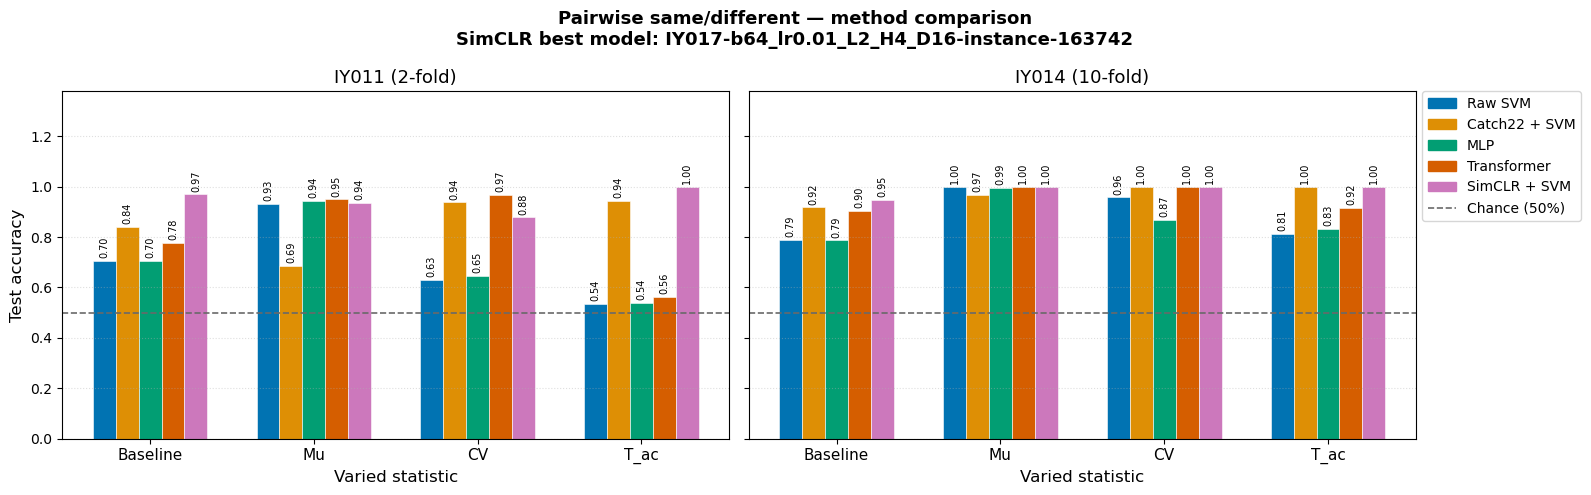

Saved IY029_pairwise_method_comparison.png


In [3]:
# ── Grouped bar comparison — 1×2 subplots (one per fold magnitude) ───────────
palette   = sns.color_palette('colorblind', n_colors=len(METHODS))
n_methods = len(METHODS)
n_ds      = len(DS_NAMES)
width     = 0.14
offsets   = np.linspace(-(n_methods - 1) / 2 * width,
                         (n_methods - 1) / 2 * width, n_methods)
x         = np.arange(n_ds)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (fold_key, fold_title) in zip(axes, FOLDS):
    for j, (label, data) in enumerate(METHODS):
        accs = [data[ds][fold_key] for ds in DS_NAMES]
        bars = ax.bar(x + offsets[j], accs, width=width,
                      color=palette[j], label=label,
                      edgecolor='white', linewidth=0.4)
        ax.bar_label(bars, fmt='%.2f', padding=2,
                     fontsize=7, rotation=90, label_type='edge')

    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(DS_NAMES, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.38)   # extra headroom for rotated labels above 1.0 bars
    ax.set_title(fold_title, fontsize=13)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

axes[0].set_ylabel('Test accuracy', fontsize=12)

legend_handles = [
    mpatches.Patch(color=palette[j], label=label)
    for j, (label, _) in enumerate(METHODS)
] + [plt.Line2D([0], [0], color='dimgrey', linestyle='--',
                linewidth=1.2, label='Chance (50%)')]
axes[1].legend(handles=legend_handles, fontsize=10,
               bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

fig.suptitle(
    f'Pairwise same/different — method comparison\n'
    f'SimCLR best model: {simclr_best_label}',
    fontsize=13, weight='bold',
)
plt.tight_layout()
plt.savefig('IY029_pairwise_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_pairwise_method_comparison.png')

In [4]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for label, data in METHODS:
    for fold_key, fold_title in FOLDS:
        row = {'Method': label, 'Fold': fold_title}
        for ds in DS_NAMES:
            row[ds] = data[ds][fold_key]
        row['Mean'] = np.mean([data[ds][fold_key] for ds in DS_NAMES])
        rows.append(row)

df = pd.DataFrame(rows).set_index(['Method', 'Fold'])
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.to_string())

print('\n── Best method per condition ──')
for fold_key, fold_title in FOLDS:
    print(f'\n{fold_title}')
    for ds in DS_NAMES:
        best_method = max(METHODS, key=lambda m: m[1][ds][fold_key])
        print(f'  {ds:<12}: {best_method[0]:<20} ({best_method[1][ds][fold_key]:.3f})')

                               Baseline    Mu    CV  T_ac  Mean
Method        Fold                                             
Raw SVM       IY011 (2-fold)      0.705 0.933 0.632 0.535 0.701
              IY014 (10-fold)     0.788 0.998 0.958 0.813 0.890
Catch22 + SVM IY011 (2-fold)      0.840 0.687 0.938 0.943 0.852
              IY014 (10-fold)     0.918 0.967 1.000 1.000 0.971
MLP           IY011 (2-fold)      0.705 0.943 0.645 0.540 0.708
              IY014 (10-fold)     0.787 0.995 0.868 0.833 0.871
Transformer   IY011 (2-fold)      0.777 0.950 0.968 0.563 0.815
              IY014 (10-fold)     0.903 1.000 1.000 0.915 0.955
SimCLR + SVM  IY011 (2-fold)      0.970 0.935 0.878 1.000 0.946
              IY014 (10-fold)     0.948 1.000 1.000 1.000 0.987

── Best method per condition ──

IY011 (2-fold)
  Baseline    : SimCLR + SVM         (0.970)
  Mu          : Transformer          (0.950)
  CV          : Transformer          (0.968)
  T_ac        : SimCLR + SVM         (1.000)

IY